# Relatório Operacional de Pré-Decolagem

Este notebook apresenta a análise de dados de telemetria para apoio à tomada de decisão em um cenário de pré-decolagem.

## Importação das bibliotecas
Nesta etapa, são importadas as bibliotecas necessárias para leitura, tratamento e visualização dos dados, além das funções auxiliares definidas no arquivo `utils.py`.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.utils import classificar_risco, calcular_autonomia, identificar_anomalia

## Leitura da base de dados
Os dados de telemetria foram armazenados em um arquivo CSV contendo informações operacionais relevantes para a análise pré-decolagem.

In [11]:
df = pd.read_csv("../data/telemetria.csv")
df.head()

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,pressao_tanque,modulos_criticos
0,24,-15,1,92,5.8,OK
1,26,-18,1,85,5.5,OK
2,29,-20,1,70,5.0,OK
3,31,-22,0,60,4.2,ALERTA
4,22,-12,1,40,4.8,OK


## Estrutura e estatísticas descritivas
Nesta etapa, verificamos a estrutura do conjunto de dados, seus tipos de variáveis e algumas estatísticas descritivas iniciais.

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   temperatura_interna     8 non-null      int64  
 1   temperatura_externa     8 non-null      int64  
 2   integridade_estrutural  8 non-null      int64  
 3   nivel_energia           8 non-null      int64  
 4   pressao_tanque          8 non-null      float64
 5   modulos_criticos        8 non-null      str    
dtypes: float64(1), int64(4), str(1)
memory usage: 516.0 bytes


In [13]:
df.describe()

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,pressao_tanque
count,8.000000,8.000000,8.00000,8.000000,8.000000
mean,27.250000,-17.375000,0.75000,64.375000,4.937500
std,4.399675,5.012484,0.46291,23.993675,0.696804
min,22.000000,-25.000000,0.00000,25.000000,3.900000
25%,23.750000,-20.500000,0.75000,51.250000,4.500000
50%,27.000000,-17.500000,1.00000,65.000000,4.900000
75%,29.500000,-14.250000,1.00000,85.750000,5.550000
max,35.000000,-10.000000,1.00000,92.000000,5.800000


## Classificação de risco
A classificação de risco foi realizada com base em regras simples aplicadas às variáveis de integridade estrutural, energia, pressão dos tanques e status dos módulos críticos.

As categorias adotadas foram:
- Normal
- Atenção
- Crítico

In [14]:
df["classificacao_risco"] = df.apply(classificar_risco, axis=1)
df

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,pressao_tanque,modulos_criticos,classificacao_risco
0,24,-15,1,92,5.8,OK,Normal
1,26,-18,1,85,5.5,OK,Normal
2,29,-20,1,70,5.0,OK,Normal
3,31,-22,0,60,4.2,ALERTA,Crítico
4,22,-12,1,40,4.8,OK,Normal
5,35,-25,0,25,3.9,FALHA,Crítico
6,28,-17,1,55,4.6,ALERTA,Atenção
7,23,-10,1,88,5.7,OK,Normal


## Análise energética
A autonomia inicial foi estimada com base no nível de carga atual, considerando a capacidade total do sistema, o consumo previsto para a decolagem e as perdas energéticas.

In [15]:
df["autonomia_estimada_horas"] = df["nivel_energia"].apply(calcular_autonomia)
df

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,pressao_tanque,modulos_criticos,classificacao_risco,autonomia_estimada_horas
0,24,-15,1,92,5.8,OK,Normal,6.7
1,26,-18,1,85,5.5,OK,Normal,6.0
2,29,-20,1,70,5.0,OK,Normal,4.5
3,31,-22,0,60,4.2,ALERTA,Crítico,3.5
4,22,-12,1,40,4.8,OK,Normal,1.5
5,35,-25,0,25,3.9,FALHA,Crítico,0.0
6,28,-17,1,55,4.6,ALERTA,Atenção,3.0
7,23,-10,1,88,5.7,OK,Normal,6.3


## Identificação de anomalias
Nesta etapa, foram identificadas possíveis anomalias operacionais, como temperatura interna elevada, falha estrutural, pressão baixa, energia crítica e falha em módulos críticos.

In [16]:
df["anomalias"] = df.apply(identificar_anomalia, axis=1)
df

,temperatura_interna,temperatura_externa,integridade_estrutural,nivel_energia,pressao_tanque,modulos_criticos,classificacao_risco,autonomia_estimada_horas,anomalias
0,24,-15,1,92,5.8,OK,Normal,6.7,Nenhuma
1,26,-18,1,85,5.5,OK,Normal,6.0,Nenhuma
2,29,-20,1,70,5.0,OK,Normal,4.5,Nenhuma
3,31,-22,0,60,4.2,ALERTA,Crítico,3.5,"Temperatura interna alta, Falha estrutural, Pr..."
4,22,-12,1,40,4.8,OK,Normal,1.5,Nenhuma
5,35,-25,0,25,3.9,FALHA,Crítico,0.0,"Temperatura interna alta, Falha estrutural, Pr..."
6,28,-17,1,55,4.6,ALERTA,Atenção,3.0,Nenhuma
7,23,-10,1,88,5.7,OK,Normal,6.3,Nenhuma


## Visualização gráfica
A seguir, apresentamos um gráfico da distribuição das classificações de risco encontradas no conjunto de dados.

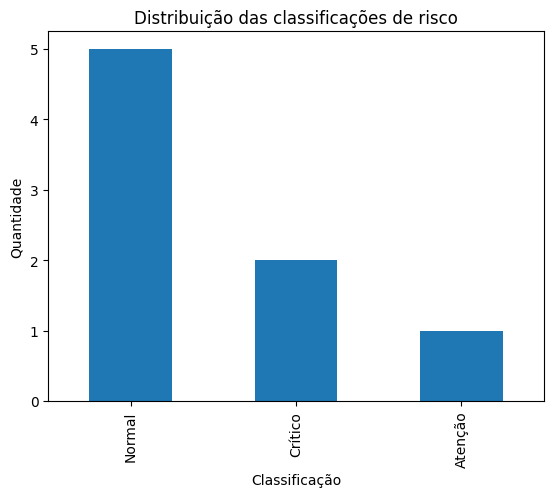

In [17]:
df["classificacao_risco"].value_counts().plot(kind="bar")
plt.title("Distribuição das classificações de risco")
plt.xlabel("Classificação")
plt.ylabel("Quantidade")
plt.show()

## Interpretação dos resultados
Com base na análise realizada, foi possível observar que parte dos registros apresenta condições normais de operação, enquanto outros indicam situações de atenção ou criticidade.

A aplicação de regras para classificação de risco e detecção de anomalias permitiu identificar registros com falhas estruturais, energia insuficiente, pressão inadequada nos tanques e falhas em módulos críticos, fatores que podem comprometer a segurança operacional em um processo de pré-decolagem.

## Reflexão crítica
O uso de sistemas computacionais e técnicas de inteligência artificial em cenários de pré-decolagem pode aumentar a eficiência da análise e reduzir erros humanos. No entanto, esse uso exige responsabilidade, transparência e validação dos critérios adotados.

Do ponto de vista ético, decisões automatizadas em contextos críticos devem sempre ser supervisionadas, principalmente quando envolvem segurança operacional. Além disso, a exploração espacial e o desenvolvimento tecnológico precisam considerar impactos sociais, custos de implementação e questões de sustentabilidade tecnológica a longo prazo.